# Environmental Data Processing for Noise Analysis
This notebook accesses the NDVI and the weather data for Glasgow and Edinburgh using sentinel hub and NASA's power APIs. Both of these require authentication, which will be linked. 

# Useful Links
Sentinel Hub Links:
* [Create account with Sentinel Hub](https://login.planet.com/u/login/identifier?state=hKFo2SBEZ19RbE04N0RSeE9MR1J1Qm5vbDR2clRrbUlMQWtZcaFur3VuaXZlcnNhbC1sb2dpbqN0aWTZIFgzRVM4NERUYWowWnp2Xy1tVl9jbDNhbGJtMWppVlhCo2NpZNkgNkFqNVRYNE1OQ2xsUlZpOUM0bVBESDBlTFV3b0VzM0g)
* [Request Builder](https://apps.sentinel-hub.com/requests-builder/)
* [Beginner's Guide](https://docs.sentinel-hub.com/api/latest/user-guides/beginners-guide/#:~:text=Requests%20Builder%20is%20a%20user-friendly%20graphical%20interface%20designed,way%20to%20get%20an%20image%20from%20Sentinel%20Hub.)
* [Processing API](https://docs.sentinel-hub.com/api/latest/api/process/)

POWER API Links
* [Documentation](https://power.larc.nasa.gov/docs/tutorials/api-getting-started/#:~:text=This%20tutorial%20will%20help%20users%20get%20started%20using,connect%20and%20interact%20with%20POWER%20%27s%20Data%20Archive.)

## NDVI API

## Bounding Boxes: 
* [-3.323319,55.890496,-3.069260,55.990097] = Edinburgh 
* [
  -4.393185527198364,
  55.78127484592951,
  -4.071705352343756,
  55.92963532489984
] = Glasgow

### Libraries Imported

In [ ]:
# Importing the library, reading the authentication codes
import sentinelhub
from sentinelhub.config import SHConfig

with open("MISC/SH_Secret.txt", "r") as file:
    CLIENT_SECRET = file.read()  # Reads the entire content and removes extra spaces/newlines
with open("MISC/SH_ID.txt", "r") as file:
    CLIENT_ID = file.read()
CLIENT_ID

In [ ]:
# Magics 
%reload_ext autoreload
%autoreload 2 
%matplotlib inline

In [ ]:
# All libraries 
import os 
import datetime
import numpy as np 
import matplotlib.pyplot as plt

from sentinelhub import (
    CRS,
    BBox,
    DataCollection,
    DownloadRequest,
    MimeType, # Format 
    MosaickingOrder,
    SentinelHubDownloadClient,
    SentinelHubRequest,
    bbox_to_dimensions,
)
from utils import plot_image # from a file in the folder 

In [ ]:
# Setting up the request 
from sentinelhub import SentinelHubRequest, DataCollection, MimeType, CRS, BBox, SHConfig, Geometry
config = SHConfig()
config.sh_client_id = CLIENT_ID
config.sh_client_secret = CLIENT_SECRET

# Exact NDVI values 
As a note, this does not average NDVI values, but rather takes a random one that fits the mosaicking specification between the time period provided. For an average, see the [time series NDVI](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/ndvi_time_series/). 

#### **NDVI Summer 2022**
June 1st to july 31st 

[Documentation, Sentinel Hub](https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Data/S2L2A.html)

In [ ]:
evalscript = """
//VERSION=3
function setup() {
  return{
    input: [{
      bands: ["B04", "B08"],
      units: "REFLECTANCE"
    }],
    output: {
      id: "default",
      bands: 1,
      sampleType: SampleType.FLOAT32
    }
  }
}

function evaluatePixel(sample) {
  let ndvi = (sample.B08 - sample.B04) / (sample.B08 + sample.B04)
  return [ ndvi ]
}
"""
bbox = BBox(bbox=[-3.449520340934233, 55.81878982882715, -3.07505516303879, 56.00408008709635], crs=CRS.WGS84) # Note to change this depending on which city it is run for

request = SentinelHubRequest(
    evalscript=evalscript,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DataCollection.SENTINEL2_L2A,          
            time_interval=('2022-06-01', '2022-07-31'),          
            other_args={"dataFilter": {"maxCloudCoverage": 5,"mosaickingOrder": "leastCC"}}
        ),
    ],
    responses=[
        SentinelHubRequest.output_response('default', MimeType.TIFF),
    ],
    bbox=bbox,
    
    size=[1431.44, 1260.735],

    config=config
)

response = request.get_data()
image = response[0]
plot_image(image, factor=1/255, clip_range=(0,1))

#### Downloading Summer 2022 as TIFF

In [ ]:
# Georeferenced 
import rasterio
from rasterio.transform import from_bounds

# Define bounding box (same as SentinelHub request), remember to change  !
minx, miny, maxx, maxy = [-3.449520340934233, 55.81878982882715, -3.07505516303879, 56.00408008709635] 
# Extract TIFF data
ndvi_tiff = response[0]  
height, width = ndvi_tiff.shape  

# Create the affine transform (maps pixels to coordinates)
transform = from_bounds(minx, miny, maxx, maxy, width, height)

# Define output file path
output_file = "./Edinburgh/env_data/NDVI/summer_2022/ndvi_summer_2022.tiff"

# Save the NDVI GeoTIFF with georeferencing
with rasterio.open(output_file, "w",
                   driver="GTiff",
                   height=height,
                   width=width,
                   count=1,  # Single-band TIFF
                   dtype=ndvi_tiff.dtype,
                   crs="EPSG:4326",  # Assign correct CRS
                   transform=transform) as dst:  
    dst.write(ndvi_tiff, 1)  

print(f"✅ Georeferenced NDVI GeoTIFF saved as {output_file}")

#### **NDVI Winter 2023** 
November 1st to January 1st 

In [ ]:
evalscript = """
//VERSION=3
function setup() {
  return{
    input: [{
      bands: ["B04", "B08"],
      units: "REFLECTANCE"
    }],
    output: {
      id: "default",
      bands: 1,
      sampleType: SampleType.FLOAT32
    }
  }
}

function evaluatePixel(sample) {
  let ndvi = (sample.B08 - sample.B04) / (sample.B08 + sample.B04)
  return [ ndvi ]
}
"""
bbox = BBox(bbox=[-3.449520340934233, 55.81878982882715, -3.07505516303879, 56.00408008709635], crs=CRS.WGS84) #Note to change depending on study area

request = SentinelHubRequest(
    evalscript=evalscript,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DataCollection.SENTINEL2_L2A,          
            time_interval=('2023-11-01', '2024-01-31'),          
            other_args={"dataFilter": {"maxCloudCoverage": 5,"mosaickingOrder": "leastCC"},"processing": {"harmonizeValues": "True"}}
        ),
    ],
    responses=[
        SentinelHubRequest.output_response('default', MimeType.TIFF),
    ],
    bbox=bbox,
    size=[1431.44, 1260.735], # Note this is the same as the summer, for edi 
    config=config
)

response = request.get_data()
image = response[0]
plot_image(image, factor=1/255, clip_range=(0,1))

#### Downloading winter 2023 as tiff 

In [ ]:
# Georeferenced 
import rasterio
from rasterio.transform import from_bounds

# Define bounding box (same as SentinelHub request)
minx, miny, maxx, maxy = [-3.449520340934233, 55.81878982882715, -3.07505516303879, 56.00408008709635]


# Extract TIFF data
ndvi_tiff = response[0]  
height, width = ndvi_tiff.shape  

# Create the affine transform (maps pixels to coordinates)
transform = from_bounds(minx, miny, maxx, maxy, width, height)

# Define output file path
output_file = "./Edinburgh/env_data/NDVI/winter_2023/ndvi_winter_2023.tiff"

# Save the NDVI GeoTIFF with georeferencing
with rasterio.open(output_file, "w",
                   driver="GTiff",
                   height=height,
                   width=width,
                   count=1,  # Single-band TIFF
                   dtype=ndvi_tiff.dtype,
                   crs="EPSG:4326",  # Assign correct CRS
                   transform=transform) as dst:  
    dst.write(ndvi_tiff, 1)  

print(f"✅ Georeferenced NDVI GeoTIFF saved as {output_file}")

# Preparing NDVI to Groundcover format for NoiseModelling

Noise Modelling classification of ground absorption 
| Description                                          | G  |
|------------------------------------------------------|----|
| Very soft (snow or moss‐like)                        | 1  |
| Soft forest floor (short, dense heather or thick moss) | 1  |
| Uncompacted, loose ground (turf, grass, loose soil)  | 1  |
| Normal uncompacted ground (forest floors, pasture field) | 1  |
| Compacted field and gravel (compacted lawns, park area) | 0.7 |
| Compacted dense ground (gravel road, car park)       | 0.3 |
| Hard surfaces (most normal asphalt, concrete)        | 0  |
| Very hard and dense surfaces (dense asphalt, concrete, water) | 0  |


NDVI basic classification 
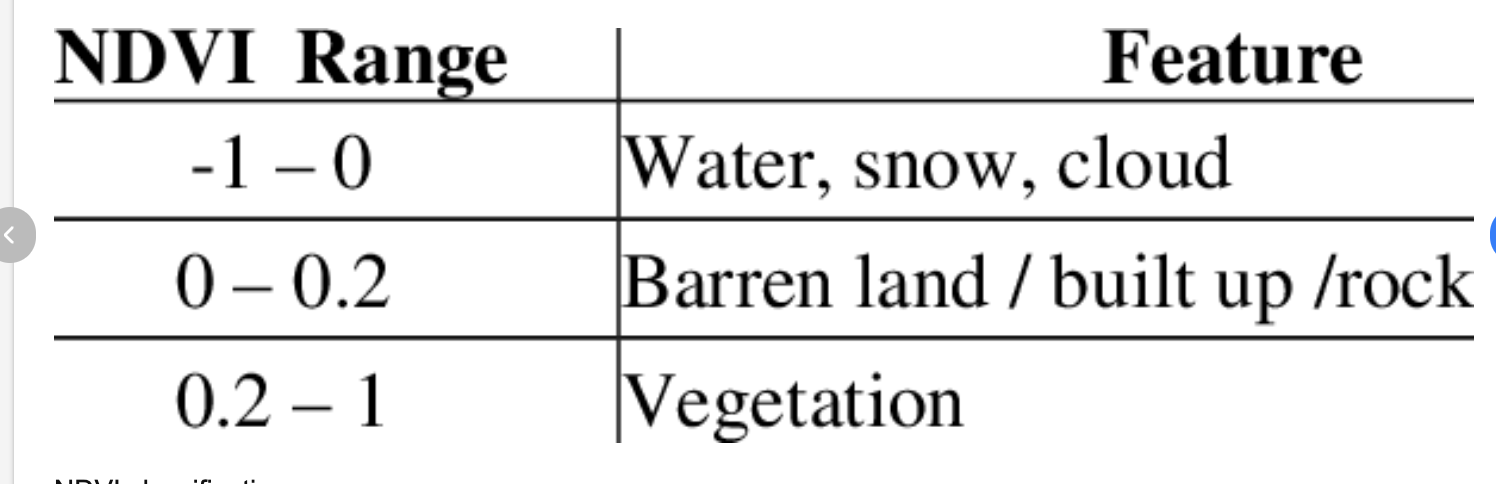

Note that the hard ground absoption values are 0, while the high vegetation values for NDVI will be around 1. Easy to get confused! 

In [ ]:
import rasterio
import numpy as np 

## Reclassifying the NDVI

In [ ]:
import os
os.getcwd()

In [ ]:
import rasterio
import numpy as np

# Input and output file paths
'''
input_raster = "./Edinburgh/env_data/NDVI/summer_2022/ndvi_summer_2022.tiff" # Summer raster 
output_raster = "./Edinburgh/env_data/NDVI/summer_2022/ndvi_summer_2022_normalized.tiff" # Summer raster 
'''
input_raster = "./Edinburgh/env_data/NDVI/winter_2023/ndvi_winter_2023.tiff" # Winter raster 
output_raster = "./Edinburgh/env_data/NDVI/winter_2023/ndvi_winter_2023_normalized.tiff" #Winter Raster 

# Open the input raster
with rasterio.open(input_raster) as src:
    ndvi = src.read(1)  # Read the NDVI band
    profile = src.profile  # Get the metadata

# Define the original NDVI value range (min and max), this is based on NDVI typical range [-1, 1]
original_min = -1
original_max = 1

# Define the target value range (min and max), we want it normalized to [0, 1]
target_min = 0
target_max = 1

# Apply min-max normalization to scale the NDVI values to [0, 1]
normalized_ndvi = (ndvi - original_min) / (original_max - original_min) * (target_max - target_min) + target_min

# Update profile to ensure the data type is appropriate
profile.update(dtype=rasterio.float32)

# Save the normalized NDVI raster to the output file
with rasterio.open(output_raster, "w", **profile) as dst:
    dst.write(normalized_ndvi.astype(np.float32), 1)

print("Normalization complete! Saved as", output_raster)

Now the values of the raster go from 0 to 1, with 1 meaning vegetation and water meaning 0 

## Reprojecting raster from 4326 to 27700

In [ ]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling

# Summer Rasters 
"""
input_file = "./Edinburgh/env_data/NDVI/summer_2022/ndvi_summer_2022_normalized.tiff"
output_file = "./Edinburgh/env_data/NDVI/summer_2022/ndvi_summer_2022_reprojected.tiff"

# Winter Rasters 
"""
input_file = "./Edinburgh/env_data/NDVI/winter_2023/ndvi_winter_2023_normalized.tiff"
output_file = "./Edinburgh/env_data/NDVI/winter_2023/ndvi_winter_2023_reprojected.tiff"


# Define target CRS (EPSG:27700) 
dst_crs = "EPSG:27700"

# Open the source raster
with rasterio.open(input_file) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )

    # Define metadata for the output raster
    dst_meta = src.meta.copy()
    dst_meta.update({
        "crs": dst_crs,
        "transform": transform,
        "width": width,
        "height": height
    })

    # Create the reprojected raster
    with rasterio.open(output_file, "w", **dst_meta) as dst:
        for i in range(1, src.count + 1):  # Loop through all bands (if multi-band)
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest
            )

print(f"✅ Reprojected NDVI GeoTIFF saved as {output_file}")

## Clipping NDVI 

In [ ]:
import rasterio
import geopandas as gpd
from rasterio.mask import mask

# File paths
outline_geojson = "./Edinburgh/Boundary/Edinburgh_City_Bounds/edi_outline.geojson" # Remember this is in 27700

# Summer Reprojected Raster 
'''
reprojected_raster = "./Edinburgh/env_data/NDVI/summer_2022/ndvi_summer_2022_reprojected.tiff"
output_clipped_raster = "./Edinburgh/env_data/NDVI/summer_2022/ndvi_summer_2022_clipped.tiff"

# Winter Reprojected Raster 
'''
reprojected_raster = "./Edinburgh/env_data/NDVI/winter_2023/ndvi_winter_2023_reprojected.tiff"
output_clipped_raster = "./Edinburgh/env_data/NDVI/winter_2023/ndvi_winter_2023_clipped.tiff" 

# Load the outline geometry from the GeoJSON
gdf = gpd.read_file(outline_geojson)

# Ensure the GeoJSON and raster CRS match
with rasterio.open(reprojected_raster) as src:
    if src.crs != gdf.crs:
        gdf = gdf.to_crs(src.crs)  # Reproject the GeoJSON to match the raster

    # Convert geometries to JSON-like format for rasterio
    shapes = [feature["geometry"] for feature in gdf.__geo_interface__["features"]]

    # Clip the raster using the boundary shapes
    out_image, out_transform = mask(src, shapes, crop=True)

    # Update metadata
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

# Save the clipped raster
with rasterio.open(output_clipped_raster, "w", **out_meta) as dst:
    dst.write(out_image)

print(f"✅ Clipped raster saved as {output_clipped_raster}")

## Transforming NDVI raster to a polygon geojson

In [ ]:
import rasterio
from rasterio import features
import geopandas as gpd
from shapely.geometry import shape
import numpy as np

# Summer file paths
'''
clipped_raster = "./Edinburgh/env_data/NDVI/summer_2022/ndvi_summer_2022_clipped.tiff"
output_geojson = "./Edinburgh/env_data/NDVI/summer_2022/ndvi_summer_2022_ground_absorption.geojson"
'''
# Winter File Paths 


clipped_raster = "./Edinburgh/env_data/NDVI/winter_2023/ndvi_winter_2023_clipped.tiff"
output_geojson = "./Edinburgh/env_data/NDVI/winter_2023/ndvi_winter_2023_ground_absorption.geojson"

# Open the raster file
with rasterio.open(clipped_raster) as src:
    ndvi = src.read(1)  # Read the first band (NDVI)
    transform = src.transform  # Get the transform (spatial reference)
    crs = src.crs  # Coordinate reference system (CRS)

# Convert raster to vector polygons, keeping only valid values (ignoring NoData)
results = features.shapes(ndvi, transform=transform)

# Prepare lists for geometry and values
geometries = []
absorption_values = []

# Loop through each raster cell converted to a polygon
for geometry, value in results:
    if not np.isnan(value):  # Ensure we do not include NoData values
        geometries.append(shape(geometry))  # Convert JSON geometry to Shapely
        absorption_values.append(float(value))  # Store NDVI value as "G"

# Convert to a GeoDataFrame
gdf = gpd.GeoDataFrame({"geometry": geometries, "G": absorption_values}, crs=crs)

# Save as a GeoJSON
#gdf.to_file(output_geojson, driver="GeoJSON")

#print(f"✅ Ground absorption file saved as: {output_geojson}")

In [ ]:
gdf.head()

In [ ]:
gdf = gdf.rename(columns={"geometry": "THE_GEOM"})
gdf = gdf.set_geometry("THE_GEOM")
#gdf.explore()

In [ ]:
# Saving Winter file 
gdf.to_file("/Users/Isaiah/Documents/Dissertation/NoiseModelling/Edinburgh/noisemodelling_inputs/groundcover/winter_2023_groundcover.geojson", driver="GeoJSON")

# Saving Summer file
#gdf.to_file("/Users/Isaiah/Documents/Dissertation/NoiseModelling/Edinburgh/noisemodelling_inputs/groundcover/sum_2022_groundcover.geojson", driver="GeoJSON")

print("done")

## Weather APIs
[Documentation Source for API](https://power.larc.nasa.gov/api/pages/)
[Data Access Viewer POWER](https://power.larc.nasa.gov/data-access-viewer/)

### API Relative Humidity at 2 Meters

In [ ]:
import requests
import pandas as pd
from io import StringIO
# Define the API URL
url = "https://power.larc.nasa.gov/api/temporal/hourly/point"
params = {
    'start': '20220627', # Use this for the beginning date 
    'end': '20220727', # use this for the end date 
    'latitude': '55.953251', # location, lat 55.953251, -3.188267
    'longitude': '-3.188267', # location long 
    'community': 're', # re means renewable energy 
    'parameters': 'RH2M', # code for wind relative humidity at 2 meters 
    'format': 'csv', 
    'user': 'issyollie',
    'header': 'false',
    'time-standard': 'utc'
}
# Send GET request to the API
response = requests.get(url, params=params)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Read the CSV data from the response into a pandas DataFrame
    data = StringIO(response.text)  # Convert string response to a file-like object
    RH2M_df = pd.read_csv(data) # read as a dataframe 
    
    # Display the first few rows of the DataFrame
    print(RH2M_df.head())
else:
    print(f"Failed to fetch data. Status code: {response.status_code}")

### API Mean Temperature at 2 Meters 

 'latitude': '55.953251', # location, lat 55.953251, -3.188267
    'longitude': '-3.188267',

gg: 
'latitude': '55.87', # location, lat 
    'longitude': '-4.26',

In [ ]:
import requests
import pandas as pd
from io import StringIO
# Define the API URL
url = "https://power.larc.nasa.gov/api/temporal/hourly/point"
params = {
    'start': '20220701', # Use this for the beginning date 
    'end': '20220730', # use this for the end date 
    'latitude': '55.953251', # location, lat 55.953251, -3.188267
    'longitude': '-3.188267',# location long 
    'community': 're', # re means renewable energy 
    'parameters': 'T2M', # code for temp at 2 meters 
    'format': 'csv', 
    'user': 'issyollie',
    'header': 'false',
    'time-standard': 'utc'
}
# Send GET request to the API
response = requests.get(url, params=params)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Read the CSV data from the response into a pandas DataFrame
    data = StringIO(response.text)  # Convert string response to a file-like object
    T2M_df = pd.read_csv(data) # read as a dataframe 
    
    # Display the first few rows of the DataFrame
    print(T2M_df.head())
else:
    print(f"Failed to fetch data. Status code: {response.status_code}")

import pandas as pd
# Assuming the dataframe is named 'df'
# Filter the rows where the month is 7
july_data = T2M_df[T2M_df['MO'] == 7]

# Calculate the average temperature for July
july_2022_T2M = july_data['T2M'].mean()